# LumenY 7 — Geometric Feature Engineering (1H)

Pure price geometry features computed from 1H, 4H, and 15M OHLCV data.
No microstructure. No tick-level signals. Only shape.

**Inputs:**
- `backend/data/processed/{PAIR}_1H.parquet` — primary feature layer
- `backend/data/processed/{PAIR}_4H.parquet` — macro regime context
- `backend/data/processed/{PAIR}_15M.parquet` — intra-hour structure

**Output:** `backend/data/features_8/` — one parquet per pair + combined file

**Feature layers:**
1. Single bar shape (close position, body ratio, wicks)
2. Sequence shape (slopes, envelope geometry, regression residual, curvature)
3. Path geometry (tortuosity, slope agreement, compression ratio)
4. Intra-hour structure from 15M bars
5. 4H macro context (closed bars only — shifted by 1 to avoid leakage)

**Target:** `label_1H = log(close[t+1] / close[t]) / ATR_24` — next 1H return normalized by ATR

**Training cutoff:** 2024-06-30

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import gc
from pathlib import Path
from scipy import stats
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../backend/data/processed')
OUTPUT_DIR    = Path('../backend/data/features_8')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PAIRS = [
    'EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY',
    'EURJPY', 'GBPJPY', 'EURGBP', 'EURAUD', 'AUDJPY', 'CADJPY', 'CHFJPY', 'AUDNZD',
]

PIP_SIZE = {
    'EURUSD': 0.0001, 'GBPUSD': 0.0001, 'AUDUSD': 0.0001, 'NZDUSD': 0.0001,
    'USDCAD': 0.0001, 'USDCHF': 0.0001, 'USDJPY': 0.01,
    'EURJPY': 0.01,   'GBPJPY': 0.01,   'EURGBP': 0.0001, 'EURAUD': 0.0001,
    'AUDJPY': 0.01,   'CADJPY': 0.01,   'CHFJPY': 0.01,   'AUDNZD': 0.0001,
}

TRAIN_END = '2024-06-30'

print(f'Pairs: {len(PAIRS)}')
print(f'Output: {OUTPUT_DIR}')
print(f'Training cutoff: {TRAIN_END}')

Pairs: 15
Output: ..\backend\data\features_8
Training cutoff: 2024-06-30


## 1. Feature Computation Functions

Each function takes aligned 1H, 4H, 15M DataFrames for a single pair
and returns a DataFrame of features indexed by 1H timestamp.

| Function | Layer | Features |
|---|---|---|
| `bar_shape_features()` | 1 — Single bar | close position, body ratio, wicks, direction |
| `sequence_shape_features()` | 2 — Sequence | slopes, envelope geometry, residual, curvature |
| `path_geometry_features()` | 3 — Path | tortuosity, slope agreement, compression |
| `intrabar_features()` | 4 — 15M intra-hour | intrabar slope, tortuosity, momentum |
| `macro_context_features()` | 5 — 4H context | 4H slope, residual, compression, close position |

In [28]:
def bar_shape_features(df_1h):
    """Layer 1: Single bar shape features.
    
    Describes the geometry of each individual 1H bar.
    All values are dimensionless ratios in [0, 1] or [-1, +1].
    """
    o = df_1h['open']
    h = df_1h['high']
    l = df_1h['low']
    c = df_1h['close']

    feat = pd.DataFrame(index=df_1h.index)
    rng  = (h - l).clip(lower=1e-10)

    # Where did close land within the bar's range? 0=bottom, 1=top
    feat['close_position']  = (c - l) / rng

    # How decisive was the bar? 1=full marubozu, 0=doji
    feat['body_ratio']      = (c - o).abs() / rng

    # Wick structure — rejection signals
    feat['upper_wick']      = (h - np.maximum(o, c)) / rng
    feat['lower_wick']      = (np.minimum(o, c) - l) / rng
    feat['wick_asymmetry']  = feat['upper_wick'] - feat['lower_wick']  # + = bearish pressure

    # Bar direction: +1 bullish, -1 bearish
    feat['bar_direction']   = np.sign(c - o).astype(np.float32)

    # Consecutive same-direction bars (last 6)
    d = feat['bar_direction']
    feat['consec_bull'] = d.rolling(6, min_periods=1).apply(lambda x: (x > 0).sum(), raw=True)
    feat['consec_bear'] = d.rolling(6, min_periods=1).apply(lambda x: (x < 0).sum(), raw=True)

    # Previous bar's close position (momentum carry)
    feat['prev_close_pos']  = feat['close_position'].shift(1)
    feat['prev_body_ratio'] = feat['body_ratio'].shift(1)

    return feat.astype(np.float32)


# Quick test
df_test = pd.read_parquet(PROCESSED_DIR / 'EURUSD_1H.parquet')
if 'datetime' in df_test.columns: df_test = df_test.set_index('datetime')
df_test.index = pd.to_datetime(df_test.index)
out = bar_shape_features(df_test)
print(f'Layer 1 — bar shape: {out.shape[1]} features')
print(out.columns.tolist())
print(out.tail(3))

Layer 1 — bar shape: 10 features
['close_position', 'body_ratio', 'upper_wick', 'lower_wick', 'wick_asymmetry', 'bar_direction', 'consec_bull', 'consec_bear', 'prev_close_pos', 'prev_body_ratio']
                     close_position  body_ratio  upper_wick  lower_wick  \
datetime                                                                  
2025-12-31 17:00:00        0.655556    0.133333    0.344444    0.522222   
2025-12-31 18:00:00        0.222222    0.400000    0.377778    0.222222   
2025-12-31 22:00:00        0.000000    0.000000    0.000000    0.000000   

                     wick_asymmetry  bar_direction  consec_bull  consec_bear  \
datetime                                                                       
2025-12-31 17:00:00       -0.177778            1.0          3.0          3.0   
2025-12-31 18:00:00        0.155556           -1.0          2.0          4.0   
2025-12-31 22:00:00        0.000000            0.0          2.0          3.0   

                     prev_c

In [29]:
def sequence_shape_features(df_1h):
    """Layer 2: Sequence shape features.

    Describes how the last N bars form a geometric pattern:
    slopes, envelope geometry (H vs L slopes), regression residual, curvature.
    All normalized by ATR to be dimensionless.
    """
    h = df_1h['high']
    l = df_1h['low']
    c = df_1h['close']

    feat = pd.DataFrame(index=df_1h.index)

    # ATR for normalization
    tr   = np.maximum(h - l, np.maximum((h - c.shift(1)).abs(), (l - c.shift(1)).abs()))
    atr  = tr.rolling(24, min_periods=4).mean().clip(lower=1e-10)
    feat['atr_24'] = atr  # keep as reference

    def norm_slope(series, n):
        """Linear regression slope over n bars, normalized by ATR."""
        def _slope(x):
            if np.isnan(x).any(): return np.nan
            xi = np.arange(len(x))
            return np.polyfit(xi, x, 1)[0]
        return series.rolling(n, min_periods=max(3, n//2)).apply(_slope, raw=True) / atr

    def regression_residual(series, n):
        """Distance of last value from its n-bar regression line, normalized by ATR."""
        def _resid(x):
            if np.isnan(x).any(): return np.nan
            xi = np.arange(len(x))
            pred = np.polyval(np.polyfit(xi, x, 1), xi[-1])
            return x[-1] - pred
        return series.rolling(n, min_periods=max(3, n//2)).apply(_resid, raw=True) / atr

    # ── Slopes of closes at multiple lookbacks ────────────────────────────
    for n, label in [(3, '3h'), (6, '6h'), (12, '12h'), (24, '24h')]:
        feat[f'slope_close_{label}'] = norm_slope(c, n)

    # ── Envelope geometry: slope of highs vs slope of lows ───────────────
    # Converging (squeeze): high_slope < 0 and low_slope > 0
    # Diverging (expansion): high_slope > 0 and low_slope < 0
    for n, label in [(6, '6h'), (12, '12h'), (24, '24h')]:
        hs = norm_slope(h, n)
        ls = norm_slope(l, n)
        feat[f'high_slope_{label}']     = hs
        feat[f'low_slope_{label}']      = ls
        feat[f'envelope_squeeze_{label}'] = hs - ls  # negative = converging = compression

    # ── Regression residual: where is close vs its own trendline ─────────
    for n, label in [(6, '6h'), (12, '12h'), (24, '24h')]:
        feat[f'residual_{label}'] = regression_residual(c, n)

    # ── Curvature: is the slope accelerating or decelerating ─────────────
    # Positive curvature = slope steepening (momentum building)
    # Negative curvature = slope flattening (momentum dying)
    feat['curvature_6h']  = feat['slope_close_6h']  - feat['slope_close_6h'].shift(3)
    feat['curvature_12h'] = feat['slope_close_12h'] - feat['slope_close_12h'].shift(6)
    feat['curvature_24h'] = feat['slope_close_24h'] - feat['slope_close_24h'].shift(12)

    return feat.astype(np.float32)


out2 = sequence_shape_features(df_test)
print(f'Layer 2 — sequence shape: {out2.shape[1]} features')
print(out2.columns.tolist())

Layer 2 — sequence shape: 20 features
['atr_24', 'slope_close_3h', 'slope_close_6h', 'slope_close_12h', 'slope_close_24h', 'high_slope_6h', 'low_slope_6h', 'envelope_squeeze_6h', 'high_slope_12h', 'low_slope_12h', 'envelope_squeeze_12h', 'high_slope_24h', 'low_slope_24h', 'envelope_squeeze_24h', 'residual_6h', 'residual_12h', 'residual_24h', 'curvature_6h', 'curvature_12h', 'curvature_24h']


In [30]:
def path_geometry_features(df_1h):
    """Layer 3: Path geometry features.

    Describes how price moved to get where it is:
    tortuosity (efficiency of path), slope agreement across timeframes,
    and compression (current range vs historical range).
    """
    h = df_1h['high']
    l = df_1h['low']
    c = df_1h['close']

    feat = pd.DataFrame(index=df_1h.index)

    tr  = np.maximum(h - l, np.maximum((h - c.shift(1)).abs(), (l - c.shift(1)).abs()))
    atr = tr.rolling(24, min_periods=4).mean().clip(lower=1e-10)

    # ── Tortuosity: how direct was the path ───────────────────────────────
    # = sum of |step returns| / |net return|
    # 1.0 = perfectly straight trend, higher = choppy/mean-reverting
    def tortuosity(series, n):
        def _tort(x):
            if np.isnan(x).any(): return np.nan
            steps   = np.abs(np.diff(x)).sum()
            net     = abs(x[-1] - x[0])
            return steps / max(net, 1e-10)
        return series.rolling(n, min_periods=max(3, n//2)).apply(_tort, raw=True)

    feat['tortuosity_6h']  = tortuosity(c, 6)
    feat['tortuosity_12h'] = tortuosity(c, 12)
    feat['tortuosity_24h'] = tortuosity(c, 24)

    # ── Slope agreement across timeframes ────────────────────────────────
    # Do short and long term slopes agree? +1 = same direction, -1 = conflict
    def norm_slope(series, n):
        def _slope(x):
            if np.isnan(x).any(): return np.nan
            return np.polyfit(np.arange(len(x)), x, 1)[0]
        return series.rolling(n, min_periods=max(3, n//2)).apply(_slope, raw=True)

    s3  = norm_slope(c, 3)
    s6  = norm_slope(c, 6)
    s12 = norm_slope(c, 12)
    s24 = norm_slope(c, 24)

    feat['slope_agree_3_12']  = (np.sign(s3)  == np.sign(s12)).astype(np.float32)
    feat['slope_agree_6_24']  = (np.sign(s6)  == np.sign(s24)).astype(np.float32)
    feat['slope_agree_3_24']  = (np.sign(s3)  == np.sign(s24)).astype(np.float32)

    # Magnitude of slope alignment: product of normalized slopes
    feat['slope_alignment_3_12'] = (s3 * s12).clip(-1, 1) / atr**2
    feat['slope_alignment_6_24'] = (s6 * s24).clip(-1, 1) / atr**2

    # ── Compression ratio ─────────────────────────────────────────────────
    # Is current range narrow relative to recent history?
    # < 1 = compression (squeeze), > 1 = expansion
    rng = h - l
    feat['compression_6_24']  = rng.rolling(6,  min_periods=3).mean() / \
                                rng.rolling(24, min_periods=6).mean().clip(lower=1e-10)
    feat['compression_12_48'] = rng.rolling(12, min_periods=6).mean() / \
                                rng.rolling(48, min_periods=12).mean().clip(lower=1e-10)

    # ── Range position: where is close in the N-bar range ────────────────
    # 0 = at bottom of N-bar range, 1 = at top
    for n, label in [(12, '12h'), (24, '24h'), (48, '48h')]:
        h_n = h.rolling(n, min_periods=n//2).max()
        l_n = l.rolling(n, min_periods=n//2).min()
        feat[f'range_pos_{label}'] = (c - l_n) / (h_n - l_n).clip(lower=1e-10)

    return feat.astype(np.float32)


out3 = path_geometry_features(df_test)
print(f'Layer 3 — path geometry: {out3.shape[1]} features')
print(out3.columns.tolist())

Layer 3 — path geometry: 13 features
['tortuosity_6h', 'tortuosity_12h', 'tortuosity_24h', 'slope_agree_3_12', 'slope_agree_6_24', 'slope_agree_3_24', 'slope_alignment_3_12', 'slope_alignment_6_24', 'compression_6_24', 'compression_12_48', 'range_pos_12h', 'range_pos_24h', 'range_pos_48h']


In [31]:
def intrabar_features(df_1h, df_15m):
    """Layer 4: Intra-hour structure from 15M bars — fully vectorized.

    For each 1H bar, uses the 4 internal 15M bars to describe
    how the hour formed geometrically. Two bars with identical OHLC
    can have very different intrabar geometry.

    Vectorized: assigns each 15M bar to its parent 1H bar via floor('1h'),
    then aggregates with groupby. Same math as the loop version, ~100x faster.
    """
    df_15m = df_15m.sort_index().copy()

    # Assign each 15M bar to its parent 1H timestamp
    df_15m['hour_ts'] = df_15m.index.floor('1h')

    # Only keep 15M bars whose parent 1H bar exists in df_1h
    valid_hours = set(df_1h.index)
    df_15m = df_15m[df_15m['hour_ts'].isin(valid_hours)]

    # Within each group (1H bar), compute bar index 0-3
    df_15m['bar_idx'] = df_15m.groupby('hour_ts').cumcount()

    # Pivot: one row per 1H bar, columns = [c0, c1, c2, c3, v0, v1, v2, v3]
    c_pivot = df_15m.pivot_table(index='hour_ts', columns='bar_idx',
                                  values='close', aggfunc='first')
    v_pivot = df_15m.pivot_table(index='hour_ts', columns='bar_idx',
                                  values='volume', aggfunc='first')
    c_pivot.columns = [f'c{i}' for i in c_pivot.columns]
    v_pivot.columns = [f'v{i}' for i in v_pivot.columns]

    # Reindex to df_1h index
    c = c_pivot.reindex(df_1h.index)
    v = v_pivot.reindex(df_1h.index)

    # 1H range for normalization
    rng_1h = (df_1h['high'] - df_1h['low']).clip(lower=1e-10)

    feat = pd.DataFrame(index=df_1h.index)

    # Slope: linear regression over [c0, c1, c2, c3]
    # For 4 evenly spaced points: slope = (-3*c0 - c1 + c2 + 3*c3) / 10
    # (exact least squares for xi = [0,1,2,3])
    has_all = c[['c0','c1','c2','c3']].notna().all(axis=1)
    slope   = pd.Series(np.nan, index=df_1h.index)
    slope[has_all] = (
        -3*c.loc[has_all,'c0'] - c.loc[has_all,'c1']
        + c.loc[has_all,'c2'] + 3*c.loc[has_all,'c3']
    ) / (10 * rng_1h[has_all])
    feat['intrabar_slope'] = slope

    # Tortuosity: sum(|steps|) / |net move|
    has_c01  = c[['c0','c1']].notna().all(axis=1)
    has_c012 = c[['c0','c1','c2']].notna().all(axis=1)

    steps = pd.Series(0.0, index=df_1h.index)
    steps[has_c01]  += (c['c1'] - c['c0']).abs()[has_c01]
    steps[has_c012] += (c['c2'] - c['c1']).abs()[has_c012]
    steps[has_all]  += (c['c3'] - c['c2']).abs()[has_all]

    net  = (c['c3'] - c['c0']).abs().clip(lower=1e-10)
    tort = pd.Series(np.nan, index=df_1h.index)
    tort[has_all] = steps[has_all] / net[has_all]
    feat['intrabar_tortuosity'] = tort

    # Close position of last 15M close in 1H range
    last_close = c['c3'].where(has_all, c['c2'].where(has_c012, c['c1'].where(has_c01, np.nan)))
    feat['intrabar_close_pos'] = (last_close - df_1h['low']) / rng_1h

    # Momentum: last step vs first step
    feat['intrabar_momentum'] = pd.Series(np.nan, index=df_1h.index)
    feat.loc[has_all, 'intrabar_momentum'] = (
        (c.loc[has_all,'c3'] - c.loc[has_all,'c2'])
        - (c.loc[has_all,'c1'] - c.loc[has_all,'c0'])
    ) / rng_1h[has_all]

    # Volume acceleration: last 2 bars vs first 2 bars
    has_v = v[['v0','v1','v2','v3']].notna().all(axis=1)
    vol_first = ((v['v0'] + v['v1']) / 2).clip(lower=1e-10)
    vol_last  =  (v['v2'] + v['v3']) / 2
    feat['intrabar_vol_accel'] = pd.Series(np.nan, index=df_1h.index)
    feat.loc[has_v, 'intrabar_vol_accel'] = (vol_last / vol_first)[has_v]

    return feat.astype(np.float32)


df_15m_test = pd.read_parquet(PROCESSED_DIR / 'EURUSD_15M.parquet')
if 'datetime' in df_15m_test.columns: df_15m_test = df_15m_test.set_index('datetime')
df_15m_test.index = pd.to_datetime(df_15m_test.index)

out4 = intrabar_features(df_test.head(200), df_15m_test)
print(f'Layer 4 — intrabar 15M: {out4.shape[1]} features')
print(out4.columns.tolist())
print(out4.dropna().head(3))

Layer 4 — intrabar 15M: 5 features
['intrabar_slope', 'intrabar_tortuosity', 'intrabar_close_pos', 'intrabar_momentum', 'intrabar_vol_accel']
                     intrabar_slope  intrabar_tortuosity  intrabar_close_pos  \
datetime                                                                       
2009-09-25 04:00:00        0.187942             2.339623            0.550936   
2009-09-25 05:00:00        0.114620             1.937500            0.959064   
2009-09-25 06:00:00       -0.050370             9.235294            0.381481   

                     intrabar_momentum  intrabar_vol_accel  
datetime                                                    
2009-09-25 04:00:00          -0.474012            2.117955  
2009-09-25 05:00:00           0.701754            1.016895  
2009-09-25 06:00:00          -0.266667            1.046204  


In [32]:
def macro_context_features(df_1h, df_4h):
    """Layer 5: 4H macro context features.

    For each 1H bar, looks up the current 4H bar and recent 4H history
    to provide macro regime context: trend direction, range position,
    compression, and residual at a higher timeframe.
    """
    feat = pd.DataFrame(index=df_1h.index)
    df_4h = df_4h.sort_index()

    # For each 1H bar, find the corresponding 4H bar (floor to 4H boundary)
    # 4H bars start at 00, 04, 08, 12, 16, 20 UTC
    def floor_4h(ts):
        return ts.floor('4h')

    # Precompute 4H features on the 4H DataFrame
    h4 = df_4h['high']
    l4 = df_4h['low']
    c4 = df_4h['close']
    r4 = (h4 - l4).clip(lower=1e-10)

    tr4  = np.maximum(r4, np.maximum((h4 - c4.shift(1)).abs(), (l4 - c4.shift(1)).abs()))
    atr4 = tr4.rolling(12, min_periods=3).mean().clip(lower=1e-10)

    def norm_slope_4h(series, n):
        def _slope(x):
            if np.isnan(x).any(): return np.nan
            return np.polyfit(np.arange(len(x)), x, 1)[0]
        return series.rolling(n, min_periods=max(2, n//2)).apply(_slope, raw=True) / atr4

    # 4H features computed on 4H index
    slope_4h_2  = norm_slope_4h(c4, 2)   # last 8H slope
    slope_4h_4  = norm_slope_4h(c4, 4)   # last 16H slope
    slope_4h_6  = norm_slope_4h(c4, 6)   # last 24H slope
    close_pos_4h = (c4 - l4) / r4         # close position in 4H bar
    compression_4h = r4.rolling(3, min_periods=2).mean() / \
                     r4.rolling(12, min_periods=4).mean().clip(lower=1e-10)

    # Residual: close vs 6-bar 4H regression
    def resid_4h(series, n):
        def _r(x):
            if np.isnan(x).any(): return np.nan
            xi = np.arange(len(x))
            pred = np.polyval(np.polyfit(xi, x, 1), xi[-1])
            return x[-1] - pred
        return series.rolling(n, min_periods=max(2, n//2)).apply(_r, raw=True) / atr4

    residual_4h = resid_4h(c4, 6)

    # Pack into a DataFrame on 4H index
    df_4h_feats = pd.DataFrame({
        '4h_slope_8h':     slope_4h_2,
        '4h_slope_16h':    slope_4h_4,
        '4h_slope_24h':    slope_4h_6,
        '4h_close_pos':    close_pos_4h,
        '4h_compression':  compression_4h,
        '4h_residual':     residual_4h,
    }, index=df_4h.index)

    # Shift by 1 bar so that at 04:00 we use the CLOSED 00:00 bar's features,
    # not the incomplete 04:00 bar whose close won't be known until 08:00.
    df_4h_feats = df_4h_feats.shift(1)

    # Forward-fill 4H features onto 1H index
    df_4h_feats_1h = df_4h_feats.reindex(
        df_4h_feats.index.union(df_1h.index)
    ).ffill().reindex(df_1h.index)

    for col in df_4h_feats_1h.columns:
        feat[col] = df_4h_feats_1h[col].values

    return feat.astype(np.float32)


df_4h_test = pd.read_parquet(PROCESSED_DIR / 'EURUSD_4H.parquet')
if 'datetime' in df_4h_test.columns: df_4h_test = df_4h_test.set_index('datetime')
df_4h_test.index = pd.to_datetime(df_4h_test.index)

out5 = macro_context_features(df_test, df_4h_test)
print(f'Layer 5 — 4H macro context: {out5.shape[1]} features')
print(out5.columns.tolist())
print(out5.dropna().head(3))

Layer 5 — 4H macro context: 6 features
['4h_slope_8h', '4h_slope_16h', '4h_slope_24h', '4h_close_pos', '4h_compression', '4h_residual']
                     4h_slope_8h  4h_slope_16h  4h_slope_24h  4h_close_pos  \
datetime                                                                     
2009-09-25 20:00:00    -0.195312     -0.064844     -0.064844      0.582888   
2009-09-28 00:00:00     0.008294     -0.071954     -0.078383      1.000000   
2009-09-28 01:00:00     0.008294     -0.071954     -0.078383      1.000000   

                     4h_compression  4h_residual  
datetime                                          
2009-09-25 20:00:00        1.044898    -0.042188  
2009-09-28 00:00:00        0.943473     0.015345  
2009-09-28 01:00:00        0.943473     0.015345  


## 2. Master Feature Computation Pipeline

Assembles all 5 layers into a single feature vector per 1H bar.
Processes one pair at a time to keep RAM under control.

In [33]:
def compute_geometric_features(pair, df_1h, df_4h, df_15m):
    """Compute all geometric features for a single pair.
    
    Args:
        pair:   pair name (str)
        df_1h:  1H OHLCV DataFrame
        df_4h:  4H OHLCV DataFrame
        df_15m: 15M OHLCV DataFrame
    
    Returns:
        DataFrame with all geometric features + label_1H + pair column
    """
    # Layer 1 — single bar shape
    f1 = bar_shape_features(df_1h)

    # Layer 2 — sequence shape
    f2 = sequence_shape_features(df_1h)

    # Layer 3 — path geometry
    f3 = path_geometry_features(df_1h)

    # Layer 4 — intrabar 15M
    f4 = intrabar_features(df_1h, df_15m)

    # Layer 5 — 4H macro context
    f5 = macro_context_features(df_1h, df_4h)

    # Label: next 1H log return normalized by ATR
    # Dividing by ATR removes session volatility bias — a 3-pip move at Asian open
    # and a 3-pip move at NY close are now worth different amounts.
    raw_ret = np.log(df_1h['close'].shift(-1) / df_1h['close'])
    tr      = np.maximum(df_1h['high'] - df_1h['low'],
                np.maximum((df_1h['high'] - df_1h['close'].shift(1)).abs(),
                           (df_1h['low']  - df_1h['close'].shift(1)).abs()))
    atr_1h  = tr.rolling(24, min_periods=4).mean().clip(lower=1e-10)
    label   = (raw_ret / atr_1h).rename('label_1H')

    # Combine — drop atr_24 from f2 (keep only in f3 implicitly via compression)
    df_out = pd.concat([f1, f2, f3, f4, f5, label], axis=1)
    df_out['pair'] = pair

    # Drop last row (label is NaN — no next bar)
    df_out = df_out.iloc[:-1]

    # Convert to float32
    float_cols = df_out.select_dtypes(include=[np.float64]).columns
    df_out[float_cols] = df_out[float_cols].astype(np.float32)

    return df_out


# Test on EURUSD
test_out = compute_geometric_features('EURUSD', df_test, df_4h_test, df_15m_test)
feature_cols_test = [c for c in test_out.columns if c not in ['pair', 'label_1H']]
print(f'Total features: {len(feature_cols_test)}')
print(f'Shape: {test_out.shape}')
print(f'\nFeature list:')
for c in feature_cols_test:
    print(f'  {c}')
print(f'\nNaN rates:')
nan_rates = test_out[feature_cols_test].isna().mean().sort_values(ascending=False)
print(nan_rates[nan_rates > 0.01])

Total features: 54
Shape: (98490, 56)

Feature list:
  close_position
  body_ratio
  upper_wick
  lower_wick
  wick_asymmetry
  bar_direction
  consec_bull
  consec_bear
  prev_close_pos
  prev_body_ratio
  atr_24
  slope_close_3h
  slope_close_6h
  slope_close_12h
  slope_close_24h
  high_slope_6h
  low_slope_6h
  envelope_squeeze_6h
  high_slope_12h
  low_slope_12h
  envelope_squeeze_12h
  high_slope_24h
  low_slope_24h
  envelope_squeeze_24h
  residual_6h
  residual_12h
  residual_24h
  curvature_6h
  curvature_12h
  curvature_24h
  tortuosity_6h
  tortuosity_12h
  tortuosity_24h
  slope_agree_3_12
  slope_agree_6_24
  slope_agree_3_24
  slope_alignment_3_12
  slope_alignment_6_24
  compression_6_24
  compression_12_48
  range_pos_12h
  range_pos_24h
  range_pos_48h
  intrabar_slope
  intrabar_tortuosity
  intrabar_close_pos
  intrabar_momentum
  intrabar_vol_accel
  4h_slope_8h
  4h_slope_16h
  4h_slope_24h
  4h_close_pos
  4h_compression
  4h_residual

NaN rates:
Series([], dtype:

## 3. Run Feature Computation

Process all 15 pairs sequentially. Each pair is loaded, processed, and saved
individually to keep RAM under control.

The intrabar (15M) computation is the slowest step — it loops over each 1H bar.

In [34]:
pair_stats = {}

for pair in PAIRS:
    print(f'\n{"="*50}')
    print(f'Processing {pair}...')

    # Load data
    def load(tf):
        df = pd.read_parquet(PROCESSED_DIR / f'{pair}_{tf}.parquet')
        if 'datetime' in df.columns: df = df.set_index('datetime')
        df.index = pd.to_datetime(df.index)
        return df.sort_index()

    df_1h  = load('1H')
    df_4h  = load('4H')
    df_15m = load('15M')
    print(f'  1H: {len(df_1h):,} bars | 4H: {len(df_4h):,} bars | 15M: {len(df_15m):,} bars')

    # Compute features
    import time
    t0     = time.time()
    df_out = compute_geometric_features(pair, df_1h, df_4h, df_15m)
    elapsed = time.time() - t0

    feat_cols = [c for c in df_out.columns if c not in ['pair', 'label_1H']]
    nan_rate  = df_out[feat_cols].isna().mean().mean()
    print(f'  Features: {len(feat_cols)} | Rows: {len(df_out):,} | '
          f'Avg NaN: {nan_rate:.1%} | Time: {elapsed:.1f}s')

    # Save per-pair
    out_path = OUTPUT_DIR / f'{pair}_geometric.parquet'
    df_out.to_parquet(out_path)
    size_mb = out_path.stat().st_size / 1e6
    print(f'  Saved: {out_path.name} ({size_mb:.1f} MB)')

    pair_stats[pair] = {
        'rows':     len(df_out),
        'features': len(feat_cols),
        'nan_rate': nan_rate,
        'size_mb':  size_mb,
    }

    del df_1h, df_4h, df_15m, df_out
    gc.collect()

print(f'\nAll {len(PAIRS)} pairs complete.')


Processing EURUSD...
  1H: 98,491 bars | 4H: 25,176 bars | 15M: 392,814 bars
  Features: 54 | Rows: 98,490 | Avg NaN: 0.0% | Time: 67.6s
  Saved: EURUSD_geometric.parquet (23.7 MB)

Processing GBPUSD...
  1H: 98,339 bars | 4H: 25,146 bars | 15M: 392,153 bars
  Features: 54 | Rows: 98,338 | Avg NaN: 0.0% | Time: 122.6s
  Saved: GBPUSD_geometric.parquet (24.1 MB)

Processing AUDUSD...
  1H: 98,748 bars | 4H: 25,252 bars | 15M: 393,786 bars
  Features: 54 | Rows: 98,747 | Avg NaN: 0.0% | Time: 90.5s
  Saved: AUDUSD_geometric.parquet (23.6 MB)

Processing NZDUSD...
  1H: 97,496 bars | 4H: 24,925 bars | 15M: 388,829 bars
  Features: 54 | Rows: 97,495 | Avg NaN: 0.0% | Time: 89.3s
  Saved: NZDUSD_geometric.parquet (23.2 MB)

Processing USDCAD...
  1H: 97,927 bars | 4H: 25,038 bars | 15M: 390,536 bars
  Features: 54 | Rows: 97,926 | Avg NaN: 0.0% | Time: 89.4s
  Saved: USDCAD_geometric.parquet (23.5 MB)

Processing USDCHF...
  1H: 97,469 bars | 4H: 24,879 bars | 15M: 389,031 bars
  Features:

## 4. Combine & Save All Pairs

In [35]:
# Load and combine all pairs
dfs = []
for pair in PAIRS:
    df = pd.read_parquet(OUTPUT_DIR / f'{pair}_geometric.parquet')
    dfs.append(df)
    print(f'  {pair}: {len(df):,} rows')

df_all = pd.concat(dfs).sort_index()
del dfs; gc.collect()

print(f'\nCombined: {df_all.shape}')
print(f'Date range: {df_all.index.min().date()} to {df_all.index.max().date()}')
print(f'Pairs: {sorted(df_all["pair"].unique())}')

  EURUSD: 98,490 rows
  GBPUSD: 98,338 rows
  AUDUSD: 98,747 rows
  NZDUSD: 97,495 rows
  USDCAD: 97,926 rows
  USDCHF: 97,468 rows
  USDJPY: 97,816 rows
  EURJPY: 98,593 rows
  GBPJPY: 98,387 rows
  EURGBP: 98,472 rows
  EURAUD: 98,356 rows
  AUDJPY: 98,875 rows
  CADJPY: 99,113 rows
  CHFJPY: 98,505 rows
  AUDNZD: 98,174 rows

Combined: (1474755, 56)
Date range: 2009-09-25 to 2025-12-31
Pairs: ['AUDJPY', 'AUDNZD', 'AUDUSD', 'CADJPY', 'CHFJPY', 'EURAUD', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPJPY', 'GBPUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY']


In [36]:
# Save combined file
out_path = OUTPUT_DIR / 'all_pairs_geometric.parquet'
df_all.to_parquet(out_path)
size_mb = out_path.stat().st_size / 1e6
print(f'Saved: {out_path} ({size_mb:.1f} MB)')
print(f'Rows: {len(df_all):,}')
print(f'Columns: {len(df_all.columns)}')

Saved: ..\backend\data\features_8\all_pairs_geometric.parquet (289.8 MB)
Rows: 1,474,755
Columns: 56


## 5. Feature Quality Check

Verify NaN rates, feature distributions, and correlation with target.

In [37]:
feature_cols = [c for c in df_all.columns if c not in ['pair', 'label_1H']]
df_train = df_all[df_all.index <= TRAIN_END]
df_test  = df_all[df_all.index >  TRAIN_END]

print(f'Feature count: {len(feature_cols)}')
print(f'Train: {len(df_train):,} rows ({df_train.index.min().date()} to {df_train.index.max().date()})')
print(f'Test:  {len(df_test):,} rows  ({df_test.index.min().date()} to {df_test.index.max().date()})')

# NaN rates
nan_rates = df_all[feature_cols].isna().mean().sort_values(ascending=False)
print(f'\nNaN rates (top 10):')
print(nan_rates.head(10))

# Correlation with label_1H
corrs = {}
for col in feature_cols:
    valid = df_train[[col, 'label_1H']].dropna()
    if len(valid) > 1000:
        corrs[col] = valid[col].corr(valid['label_1H'])

corr_series = pd.Series(corrs).sort_values(key=abs, ascending=False)
print(f'\nTop 15 features correlated with label_1H (train):')
print(f'{"Feature":<35} {"Pearson r":>10}')
print('-' * 47)
for col, r in corr_series.head(15).items():
    print(f'{col:<35} {r:>+10.4f}')

Feature count: 54
Train: 1,338,266 rows (2009-09-25 to 2024-06-28)
Test:  136,489 rows  (2024-07-01 to 2025-12-31)

NaN rates (top 10):
intrabar_vol_accel     0.004135
intrabar_momentum      0.004135
intrabar_tortuosity    0.004135
intrabar_slope         0.004135
intrabar_close_pos     0.002669
curvature_24h          0.000234
range_pos_48h          0.000234
4h_slope_16h           0.000163
4h_residual            0.000163
4h_slope_8h            0.000163
dtype: float64

Top 15 features correlated with label_1H (train):
Feature                              Pearson r
-----------------------------------------------
intrabar_close_pos                     -0.0379
close_position                         -0.0378
slope_close_3h                         -0.0323
residual_6h                            -0.0318
intrabar_momentum                      -0.0308
intrabar_slope                         -0.0298
residual_12h                           -0.0285
lower_wick                             -0.0272
slope_a

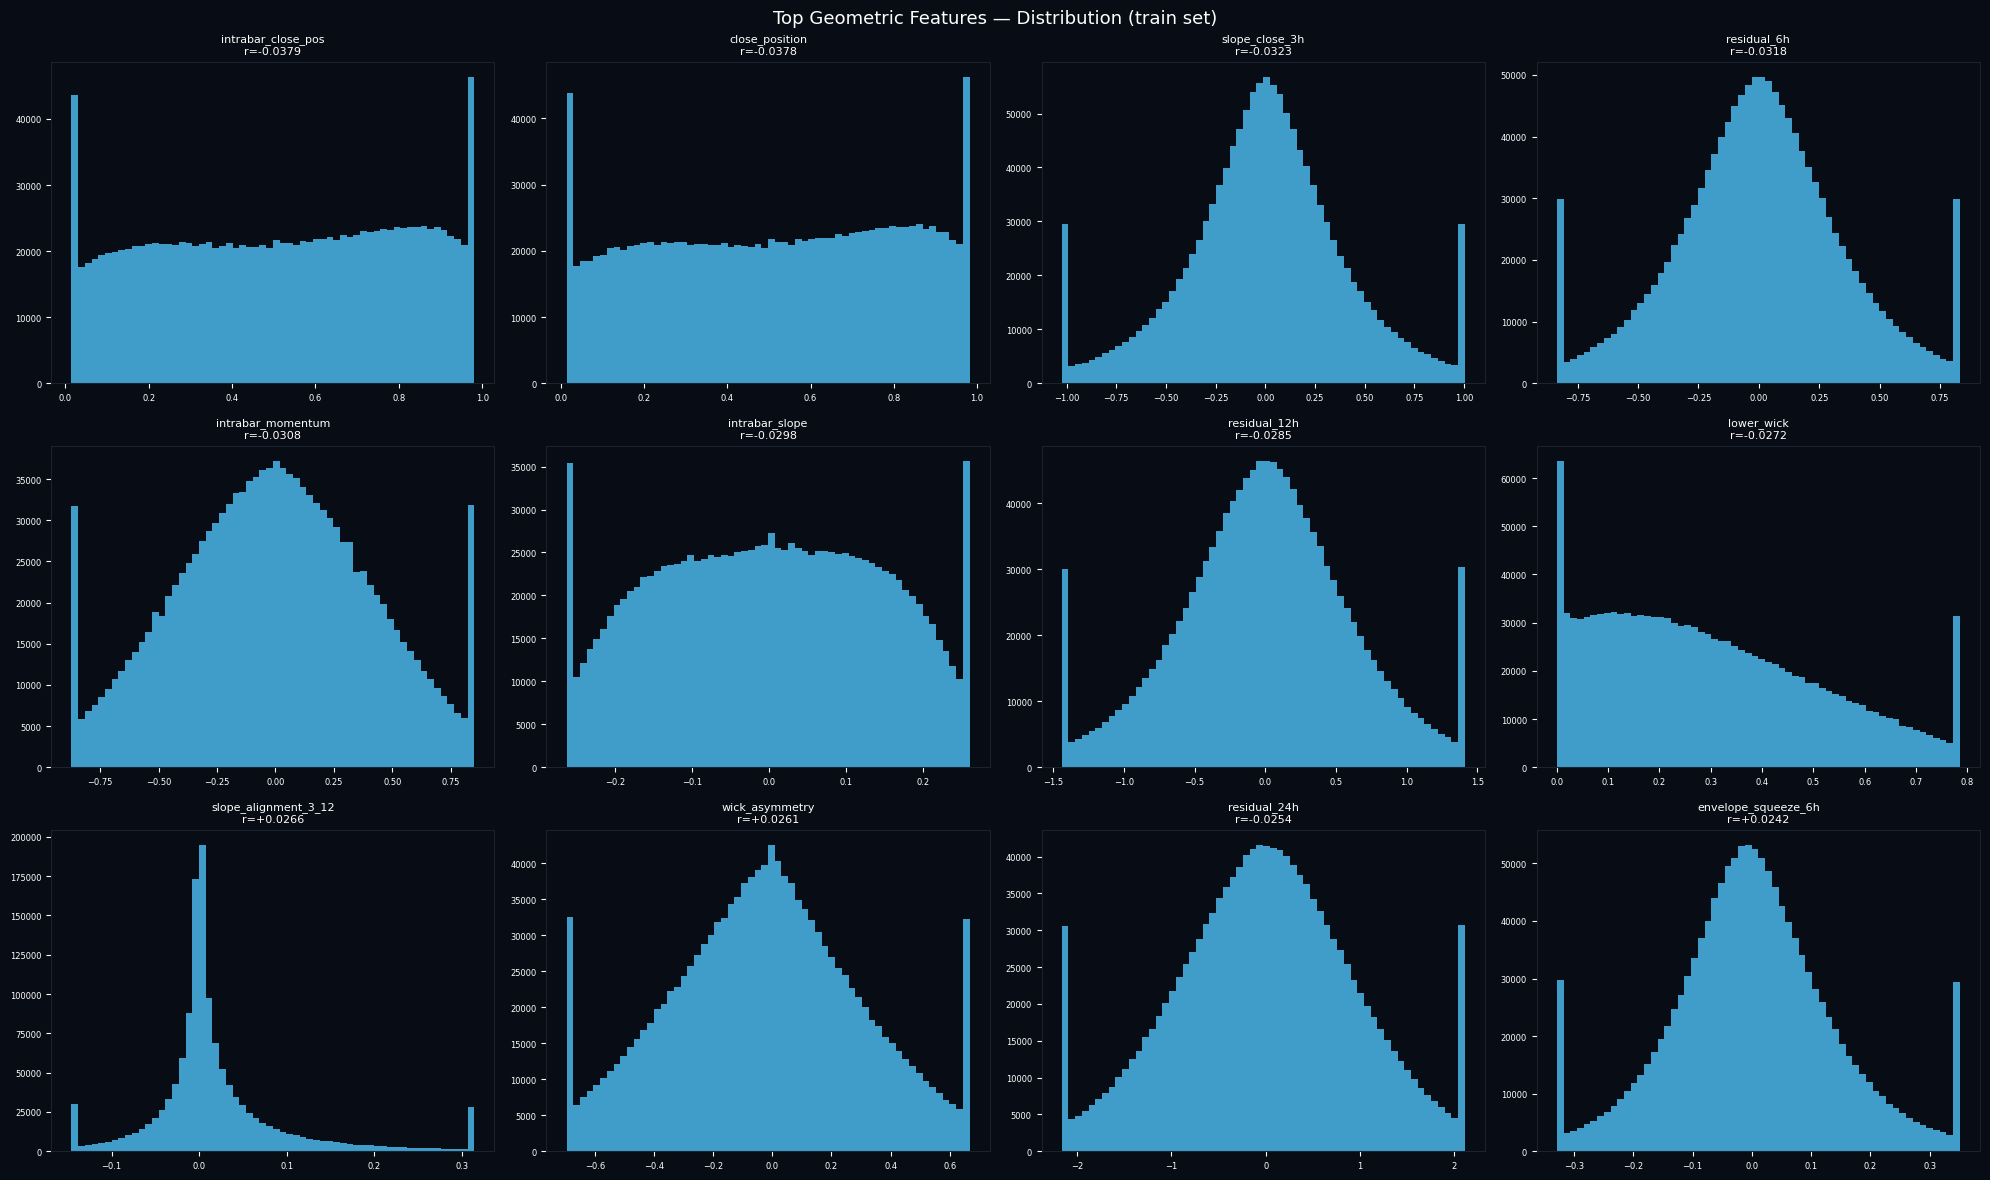

In [38]:
# Distribution plots for key features
key_features = corr_series.head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.patch.set_facecolor('#080c14')

for ax, col in zip(axes.flat, key_features):
    ax.set_facecolor('#080c14')
    vals = df_train[col].dropna()
    lo, hi = vals.quantile(0.02), vals.quantile(0.98)
    ax.hist(vals.clip(lo, hi), bins=60, color='#4fc3f7', alpha=0.8, edgecolor='none')
    ax.set_title(f'{col}\nr={corrs[col]:+.4f}', color='white', fontsize=8)
    ax.tick_params(colors='white', labelsize=6)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('Top Geometric Features — Distribution (train set)', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## Summary

In [39]:
print('=' * 60)
print('GEOMETRIC FEATURE ENGINEERING — COMPLETE')
print('=' * 60)

print(f'\nOutput directory: {OUTPUT_DIR}')
for f in sorted(OUTPUT_DIR.glob('*.parquet')):
    print(f'  {f.name:<40} {f.stat().st_size/1e6:.1f} MB')

print(f'\nPer-pair summary:')
print(f'{"Pair":<10} {"Rows":>10} {"Features":>10} {"Avg NaN":>10} {"Size MB":>10}')
print('-' * 55)
for pair, s in pair_stats.items():
    print(f'{pair:<10} {s["rows"]:>10,} {s["features"]:>10} '
          f'{s["nan_rate"]:>9.1%} {s["size_mb"]:>9.1f}')

print(f'\nFeature layers:')
print(f'  Layer 1 — Single bar shape:      close_position, body_ratio, wicks, direction')
print(f'  Layer 2 — Sequence shape:        slopes (3/6/12/24H), envelope, residual, curvature')
print(f'  Layer 3 — Path geometry:         tortuosity, slope agreement, compression, range pos')
print(f'  Layer 4 — Intrabar 15M:          intrabar slope, tortuosity, momentum, vol accel')
print(f'  Layer 5 — 4H macro context:      4H slope, close pos, compression, residual')
print(f'  Total: {len(feature_cols)} features')

print(f'\nTarget: label_1H = log(close[t+1] / close[t])')
print(f'Training cutoff: {TRAIN_END}')
print(f'\nNext step: notebooks_7/03_model_training.ipynb')

GEOMETRIC FEATURE ENGINEERING — COMPLETE

Output directory: ..\backend\data\features_8
  all_pairs_geometric.parquet              289.8 MB
  AUDJPY_geometric.parquet                 24.3 MB
  AUDNZD_geometric.parquet                 24.8 MB
  AUDUSD_geometric.parquet                 23.6 MB
  CADJPY_geometric.parquet                 24.2 MB
  CHFJPY_geometric.parquet                 25.4 MB
  EURAUD_geometric.parquet                 24.7 MB
  EURGBP_geometric.parquet                 22.9 MB
  EURJPY_geometric.parquet                 24.8 MB
  EURUSD_geometric.parquet                 23.7 MB
  GBPJPY_geometric.parquet                 25.2 MB
  GBPUSD_geometric.parquet                 24.1 MB
  NZDUSD_geometric.parquet                 23.2 MB
  USDCAD_geometric.parquet                 23.5 MB
  USDCHF_geometric.parquet                 23.4 MB
  USDJPY_geometric.parquet                 23.5 MB

Per-pair summary:
Pair             Rows   Features    Avg NaN    Size MB
----------------------